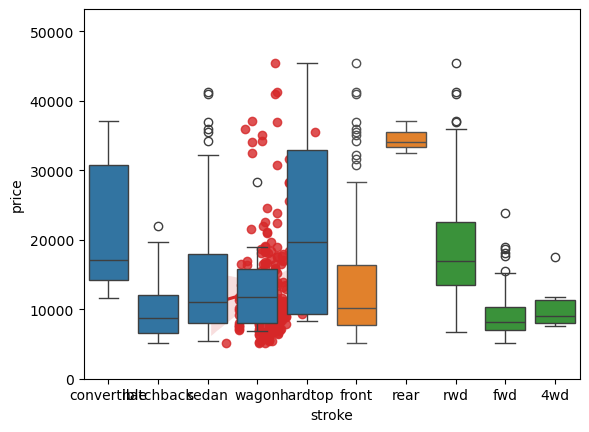

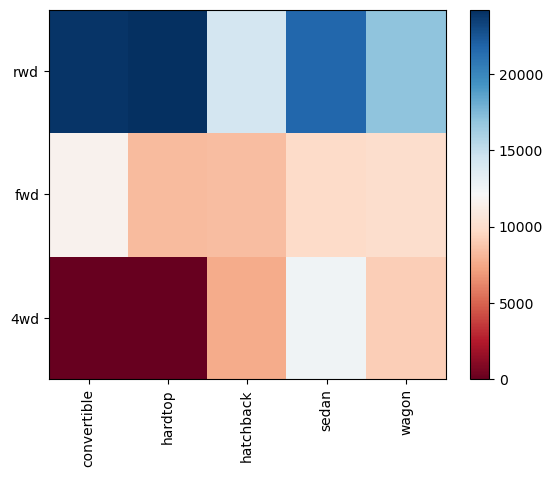

The Pearson Correlation Coefficient is 0.5846418222655081 with a P-Value of P= 8.076488270732997e-20
The Pearson Correlation Coefficient is 0.809574567003656 with a P-Value of P= 6.369057428259556e-48
The Pearson Correlation Coefficient is 0.690628380448364 with a P-Value of P= 8.016477466158763e-30
The Pearson Correlation Coefficient is 0.7512653440522674 with a P-Value of P= 9.200335510481354e-38
The Pearson Correlation Coefficient is 0.8344145257702845 with a P-Value of P= 2.189577238893955e-53
The Pearson Correlation Coefficient is 0.8723351674455185 with a P-Value of P= 9.26549162219881e-64
The Pearson Correlation Coefficient is 0.5431553832626603 with a P-Value of P= 8.04918948393528e-17
The Pearson Correlation Coefficient is -0.6865710067844679 with a P-Value of P= 2.321132065567465e-29
The Pearson Correlation Coefficient is -0.7046922650589529 with a P-Value of P= 1.7495471144476802e-31


In [52]:
import pandas as pd
import numpy as np
from pyodide.http import pyfetch
import piplite
await piplite.install("seaborn")

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, 'wb') as f:
            f.write(await response.bytes())
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"
await download(file_path, "used_cars.csv")

file_name = "used_cars.csv"

df = pd.read_csv(file_name)

df.head()

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#print(df.dtypes)

# ascertaining the data type of the "peak-rpm" column
#print(df["peak-rpm"])

# computing the correlation of only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])
#numeric_df.corr()

# ascertaining the correlation between the "bore", "stroke", "compression-ratio", and "horsepower" columns
df[["bore", "stroke", "compression-ratio", "horsepower"]].corr()

# finding a scatterplot of "engine-size" and "price"
sns.regplot(x="engine-size", y="price", data=df)
plt.ylim(0,)
#plt.show()

df[["engine-size", "price"]].corr()

# finding a scatterplot of "highway-mpg" and "price"
sns.regplot(x="highway-mpg", y="price", data=df)
plt.ylim(0,)
#plt.show()

df[["highway-mpg", "price"]].corr()

# finding a scatterplot of "peak-rpm" and "price: "peak-rpm" is not a good predictor of "price" since the regression line is close to horizontal
sns.regplot(x="peak-rpm", y="price", data=df)
plt.ylim(0,)
#plt.show()

df[["peak-rpm", "price"]].corr()

# finding a scatterplot and the correlation between "stroke" and "price"
sns.regplot(x="stroke", y="price", data=df)
plt.ylim(0,)
#plt.show()

df[["stroke", "price"]].corr()

# checking the relationship between "body-style" and "price"
sns.boxplot(x="body-style", y="price", data=df)
#plt.show()

# checking the relationship between "engine-location" and "price"
sns.boxplot(x="engine-location", y="price", data=df)
#plt.show()

# checking the relationship between "drive-wheels" and "price"
sns.boxplot(x="drive-wheels", y="price", data=df)
#plt.show()

# getting a description of the data set using the "describe()" method
df.describe(include="all")

# getting a description of the data set using the "value_counts()" method
df["drive-wheels"].value_counts()

# converting the "drive-wheels" series into a data frame "drive_wheels_counts"
drive_wheels_counts = df["drive-wheels"].value_counts().to_frame()
drive_wheels_counts.reset_index(inplace=True)
drive_wheels_counts.rename(columns={"drive-wheels": "value_counts"}, inplace=True)
#drive_wheels_counts.head()

# renaming the index to "drive-wheels"
drive_wheels_counts.index.name = "drive-wheels"
drive_wheels_counts.head()

# converting the "engine-location" series into a data frame "engine_loc_counts"
engine_loc_counts = df["engine-location"].value_counts().to_frame()
engine_loc_counts.reset_index(inplace=True)
engine_loc_counts.rename(columns={"drive-wheels": "value_counts"}, inplace=True)
#drive_wheels_counts.head()

# renaming the index to "drive-wheels"
engine_loc_counts.index.name = "engine-location"
engine_loc_counts.head()

# grouping data
df_group_one = df[["drive-wheels", "body-style", "price"]]
group_one = df_group_one.groupby(["drive-wheels"], as_index=False).agg({"price": "mean"})
group_one.head()

# grouping "drive-wheels" and "body-style" against average "price"
df_group_two = df[["drive-wheels", "body-style", "price"]]
group_two = df_group_two.groupby(["drive-wheels", "body-style"], as_index=False).mean()
group_two.head()

# forming a pivot table
group_two_pivot = group_two.pivot(index="drive-wheels", columns="body-style")
#group_two_pivot.head()

# filling missing values with 0
group_two_pivot = group_two_pivot.fillna(0)
group_two_pivot

# using a heatmap to ascertain the relationship between "price" and "body-style"
#plt.pcolor(group_two_pivot, cmap="RdBu")
#plt.colorbar()
#plt.show()

fig, ax = plt.subplots()
im = ax.pcolor(group_two_pivot, cmap='RdBu')

#label names
row_labels = group_two_pivot.columns.levels[1]
col_labels = group_two_pivot.index

#move ticks and labels to the center
ax.set_xticks(np.arange(group_two_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(group_two_pivot.shape[0]) + 0.5, minor=False)

#insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

#rotate label if too long
plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

from scipy import stats

# ascertaining the correlation between "wheel-base" and "price"
pearson_coeff, p_value = stats.pearsonr(df["wheel-base"], df["price"])
print("The Pearson Correlation Coefficient is", pearson_coeff, "with a P-Value of P=", p_value)

# ascertaining the correlation between "horsepower" and "price"
pearson_coeff, p_value = stats.pearsonr(df["horsepower"], df["price"])
print("The Pearson Correlation Coefficient is", pearson_coeff, "with a P-Value of P=", p_value)

# ascertaining the correlation between "length" and "price"
pearson_coeff, p_value = stats.pearsonr(df["length"], df["price"])
print("The Pearson Correlation Coefficient is", pearson_coeff, "with a P-Value of P=", p_value)

# ascertaining the correlation between "width" and "price"
pearson_coeff, p_value = stats.pearsonr(df["width"], df["price"])
print("The Pearson Correlation Coefficient is", pearson_coeff, "with a P-Value of P=", p_value)

# ascertaining the correlation between "curb-weight" and "price"
pearson_coeff, p_value = stats.pearsonr(df["curb-weight"], df["price"])
print("The Pearson Correlation Coefficient is", pearson_coeff, "with a P-Value of P=", p_value)

# ascertaining the correlation between "engine-size" and "price"
pearson_coeff, p_value = stats.pearsonr(df["engine-size"], df["price"])
print("The Pearson Correlation Coefficient is", pearson_coeff, "with a P-Value of P=", p_value)

# ascertaining the correlation between "bore" and "price"
pearson_coeff, p_value = stats.pearsonr(df["bore"], df["price"])
print("The Pearson Correlation Coefficient is", pearson_coeff, "with a P-Value of P=", p_value)

# ascertaining the correlation between "city-mpg" and "price"
pearson_coeff, p_value = stats.pearsonr(df["city-mpg"], df["price"])
print("The Pearson Correlation Coefficient is", pearson_coeff, "with a P-Value of P=", p_value)

# ascertaining the correlation between "highway-mpg" and "price"
pearson_coeff, p_value = stats.pearsonr(df["highway-mpg"], df["price"])
print("The Pearson Correlation Coefficient is", pearson_coeff, "with a P-Value of P=", p_value)

# The following variables are therefore important in duilding our Machine Learning Model as they have the best relationship with "price"
#Continuous numerical variables:
#Length
#Width
#Curb-weight
#Engine-size
#Horsepower
#City-mpg
#Highway-mpg
#Wheel-base
#Bore

#Categorical variables:
#Drive-wheels